In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

FIELDVARS    = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NNSEEDS      = MODELS['nn']['seeds']
OPTIMIZEDEQS = MODELS['sr']['optimizedeqs']
PODRUNS      = MODELS['pod']['runs']
NNRUNS       = MODELS['nn']['runs']
ORDER        = ['pod_bl','nn_bl','nn_full','nn_nonparam','nn_gauss','sr_lo','sr_bl','sr_med','sr_hi']

COLORS = {}
LABELS = {}
for name,config in {**PODRUNS,**NNRUNS,**OPTIMIZEDEQS}.items():
    COLORS[name] = config['color']
    LABELS[name] = config['description']

SRFUNCTIONS = {
    'cube':lambda x:x**3,
    'square':lambda x:x**2,
    'neg':lambda x:-x,
    'sqrt':np.sqrt,
    'exp':np.exp,
    'log':np.log,
    'abs':np.abs,
    'max':np.maximum,
    'min':np.minimum}

In [4]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields*weights[None,:,:]*dsig[None,None,:]
    if mask is not None:
        w = w*mask[:,None,:]
    return w.sum(axis=2)

def physical_prediction(output):
    return np.expm1(tpstd*np.maximum(0.0,np.asarray(output,dtype=float)))

def eval_form(form,variables,constants):
    ns = dict(SRFUNCTIONS)
    ns.update(variables)
    ns.update(constants)
    return np.asarray(eval(form,{'__builtins__':{}},ns),dtype=float)

def used_predictors(form,candidates):
    names = {n.id for n in ast.walk(ast.parse(form,mode='eval')) if isinstance(n,ast.Name)}
    return [c for c in candidates if c in names]

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']
    nlat  = ds.sizes['lat']
    nlon  = ds.sizes['lon']
    nsig  = ds.sizes.get('sig',1)
    lat   = ds['lat'].values
    lon   = ds['lon'].values
    dsig  = ds['dsig'].values
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)
    def getflat(da):
        if 'time' in da.dims:
            return da.transpose('time','lat','lon').values.ravel()
        return np.tile(da.values,(ntime,1,1)).ravel()
    blnorm  = getflat(ds['bl'])
    lfnorm  = getflat(ds['lf'])
    shfnorm = getflat(ds['shf'])
    lhfnorm = getflat(ds['lhf'])

kwlist = []
for seed in NNSEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)

ki = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0) if kwlist else fieldstack.mean(axis=2)
rhk,thetaek,thetaestark = ki[:,0],ki[:,1],ki[:,2]

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time','lat','lon').values.ravel()

with open(os.path.join(MODELSDIR,'sr','optimized_equations.pkl'),'rb') as f:
    SR_REGISTRY = pickle.load(f)

In [6]:
VARS = {'bl':blnorm,'rh':rhk,'thetae':thetaek,'thetaestar':thetaestark,
        'lf':lfnorm,'shf':shfnorm,'lhf':lhfnorm}

MODELPRED = {}
MODELPREDICTORS = {}
for name,cfg in OPTIMIZEDEQS.items():
    entry          = SR_REGISTRY.get(name,{})
    form           = entry.get('form',cfg['form'])
    constants      = entry.get('constants',cfg['init'])
    predictornames = used_predictors(form,VARS.keys())
    variables      = {p:VARS[p] for p in predictornames}
    formvals       = eval_form(form,variables,constants)
    MODELPRED[name]       = physical_prediction(formvals)
    MODELPREDICTORS[name] = predictornames

def load_predictions(name,predsdir,split=SPLIT):
    filepath = os.path.join(predsdir,f'{name}_{split}_predictions.nc')
    if not os.path.exists(filepath):
        return None
    with xr.open_dataset(filepath,engine='h5netcdf') as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims:
        da = da.mean('seed')
    pred = da.transpose('time','lat','lon').values.ravel()
    return pred if pred.shape[0]==obsflat.shape[0] else None

for name,cfg in PODRUNS.items():
    pred = load_predictions(name,PREDSDIR)
    if pred is None: continue
    MODELPRED[name]       = pred
    MODELPREDICTORS[name] = [cfg['inputvar']]

for name,cfg in NNRUNS.items():
    pred = load_predictions(name,PREDSDIR)
    if pred is None: continue
    MODELPRED[name]       = pred
    MODELPREDICTORS[name] = cfg['fieldvars']+cfg.get('localvars',[])

print(f'Loaded predictions for: {sorted(MODELPRED.keys())}')

Loaded predictions for: ['nn_gauss_rot', 'sr_bl', 'sr_hi', 'sr_lo', 'sr_med']


In [7]:
def to_map(flat):
    '''Reshape flat (time*lat*lon,) array to (time,lat,lon) and compute time mean.'''
    return flat.reshape(ntime,nlat,nlon).mean(axis=0)

obs_map = to_map(obsflat)
pred_maps = {name:to_map(arr) for name,arr in MODELPRED.items()}
resid_maps = {name:pred_maps[name]-obs_map for name in pred_maps}

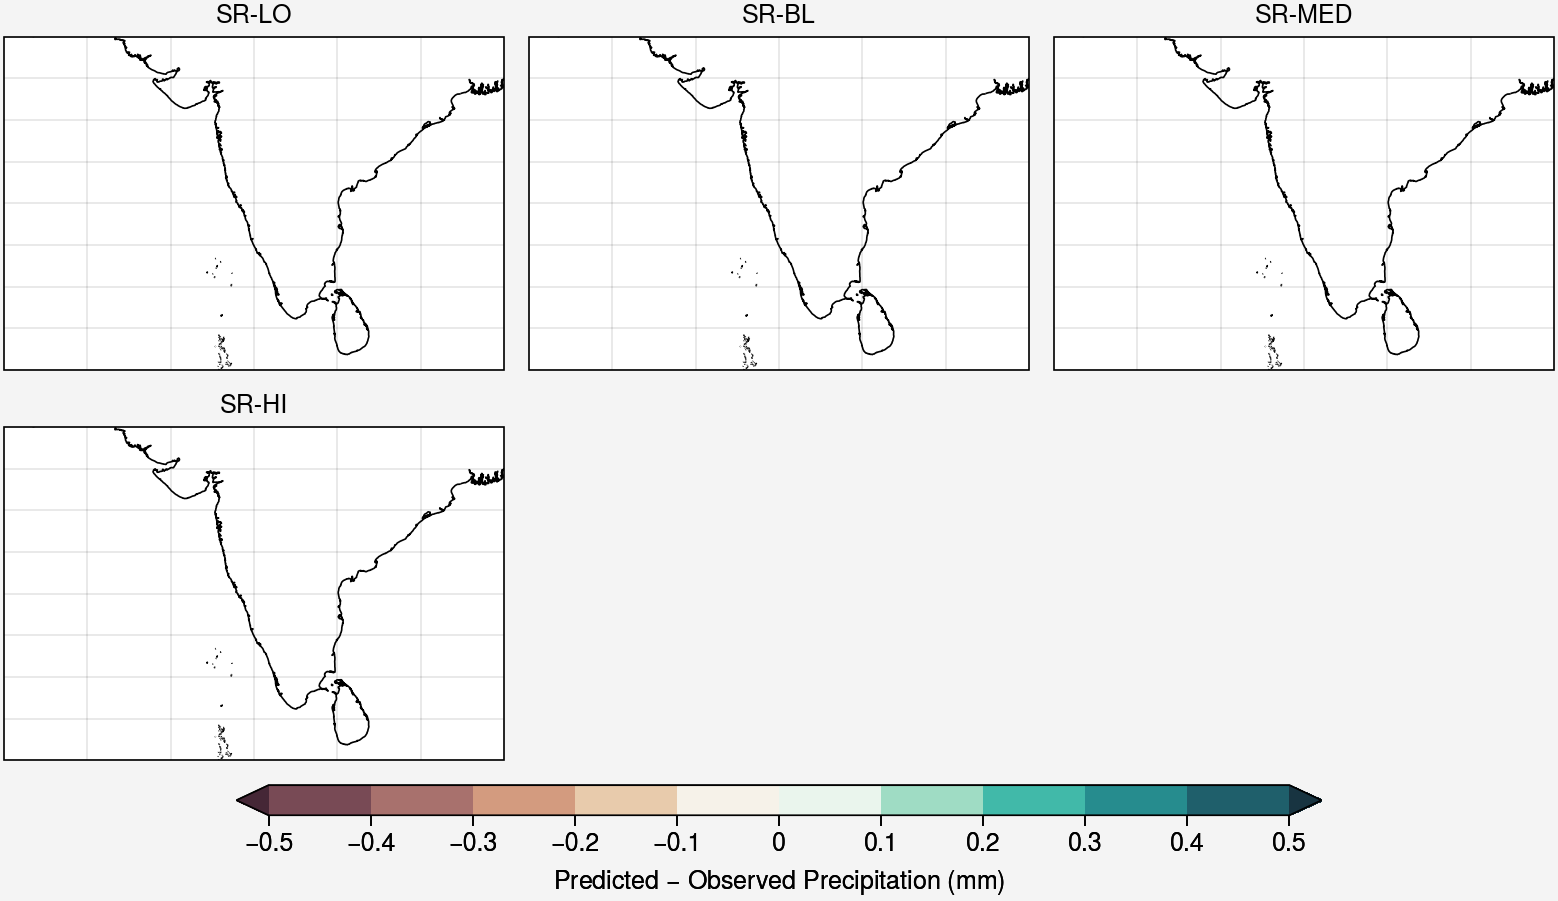

In [8]:
def plot_spatial_residuals(names=None, vlim=0.5):
    '''Time-mean (predicted - observed) precipitation maps for each model.'''
    if names is None:
        names = [n for n in ORDER if n in resid_maps]
    ncols = min(3, len(names))
    nrows = -(-len(names) // ncols)
    fig, axs = pplt.subplots(
        nrows=nrows, ncols=ncols,
        proj='cyl',
        refwidth=2.5,
        share=True)
    axs = np.atleast_1d(axs).ravel()
    m = None
    for ax, name in zip(axs, names):
        m = ax.pcolormesh(
            lon, lat, resid_maps[name],
            cmap='DryWet', vmin=-vlim, vmax=vlim, extend='both')
        ax.format(
            title=LABELS.get(name,name),
            latlim=(lat.min(),lat.max()),
            lonlim=(lon.min(),lon.max()),
            grid=True, gridminor=False,
            coast=True, borders=False)
    for ax in axs[len(names):]:
        ax.set_visible(False)
    fig.colorbar(m, loc='b', label='Predicted $-$ Observed Precipitation (mm)',
                 width=0.15, length=0.7)
    pplt.show()

plot_spatial_residuals()

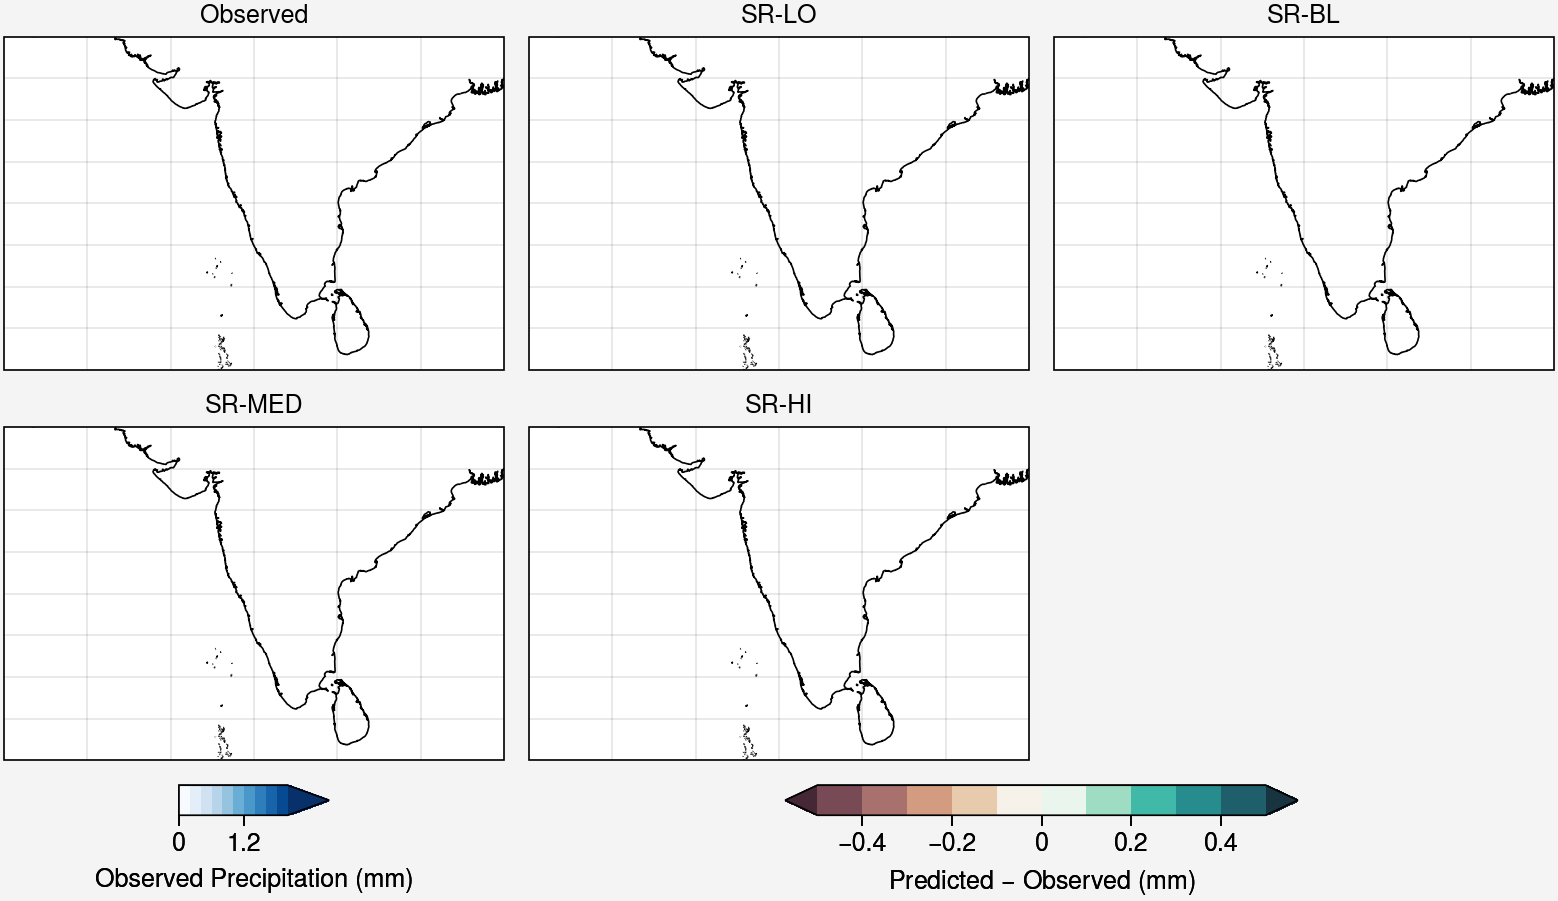

In [9]:
def plot_obs_and_residuals(names=None, vlim=0.5):
    '''First panel: time-mean observed precipitation. Remaining panels: residual maps.'''
    if names is None:
        names = [n for n in ORDER if n in resid_maps]
    all_panels = ['obs'] + names
    ncols = min(3, len(all_panels))
    nrows = -(-len(all_panels) // ncols)
    fig, axs = pplt.subplots(
        nrows=nrows, ncols=ncols,
        proj='cyl',
        refwidth=2.5,
        share=True)
    axs = np.atleast_1d(axs).ravel()
    mc, mr = None, None
    for ax, panel in zip(axs, all_panels):
        if panel == 'obs':
            mc = ax.pcolormesh(
                lon, lat, obs_map,
                cmap='Blues', vmin=0, vmax=2, extend='max')
            ax.format(title='Observed')
        else:
            mr = ax.pcolormesh(
                lon, lat, resid_maps[panel],
                cmap='DryWet', vmin=-vlim, vmax=vlim, extend='both')
            ax.format(title=LABELS.get(panel,panel))
        ax.format(
            latlim=(lat.min(),lat.max()),
            lonlim=(lon.min(),lon.max()),
            grid=True, gridminor=False,
            coast=True, borders=False)
    for ax in axs[len(all_panels):]:
        ax.set_visible(False)
    if mc is not None:
        fig.colorbar(mc, loc='b', label='Observed Precipitation (mm)',
                     width=0.15, length=0.3, col=1)
    if mr is not None:
        fig.colorbar(mr, loc='b', label='Predicted $-$ Observed (mm)',
                     width=0.15, length=0.5, col=(2,ncols))
    pplt.show()

plot_obs_and_residuals()

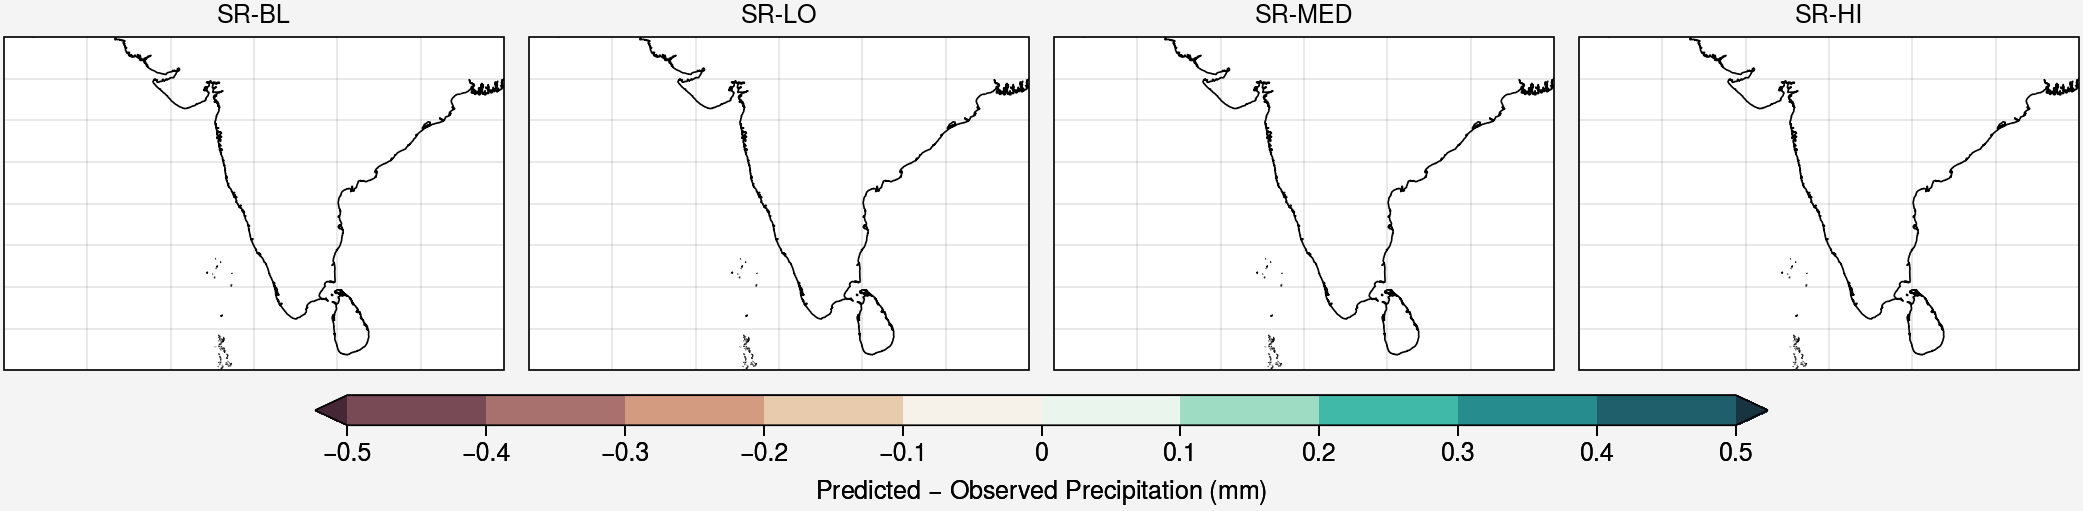

In [10]:
def plot_sr_residual_progression(vlim=0.5):
    '''Side-by-side residual maps for the SR family to show complexity vs. spatial bias trade-off.'''
    sr_names = [n for n in ['sr_bl','sr_lo','sr_med','sr_hi'] if n in resid_maps]
    fig, axs = pplt.subplots(
        nrows=1, ncols=len(sr_names),
        proj='cyl',
        refwidth=2.5,
        share=True)
    axs = np.atleast_1d(axs).ravel()
    m = None
    for ax, name in zip(axs, sr_names):
        m = ax.pcolormesh(
            lon, lat, resid_maps[name],
            cmap='DryWet', vmin=-vlim, vmax=vlim, extend='both')
        ax.format(
            title=LABELS.get(name,name),
            latlim=(lat.min(),lat.max()),
            lonlim=(lon.min(),lon.max()),
            grid=True, gridminor=False,
            coast=True, borders=False)
    fig.colorbar(m, loc='b', label='Predicted $-$ Observed Precipitation (mm)',
                 width=0.15, length=0.7)
    pplt.show()

plot_sr_residual_progression()

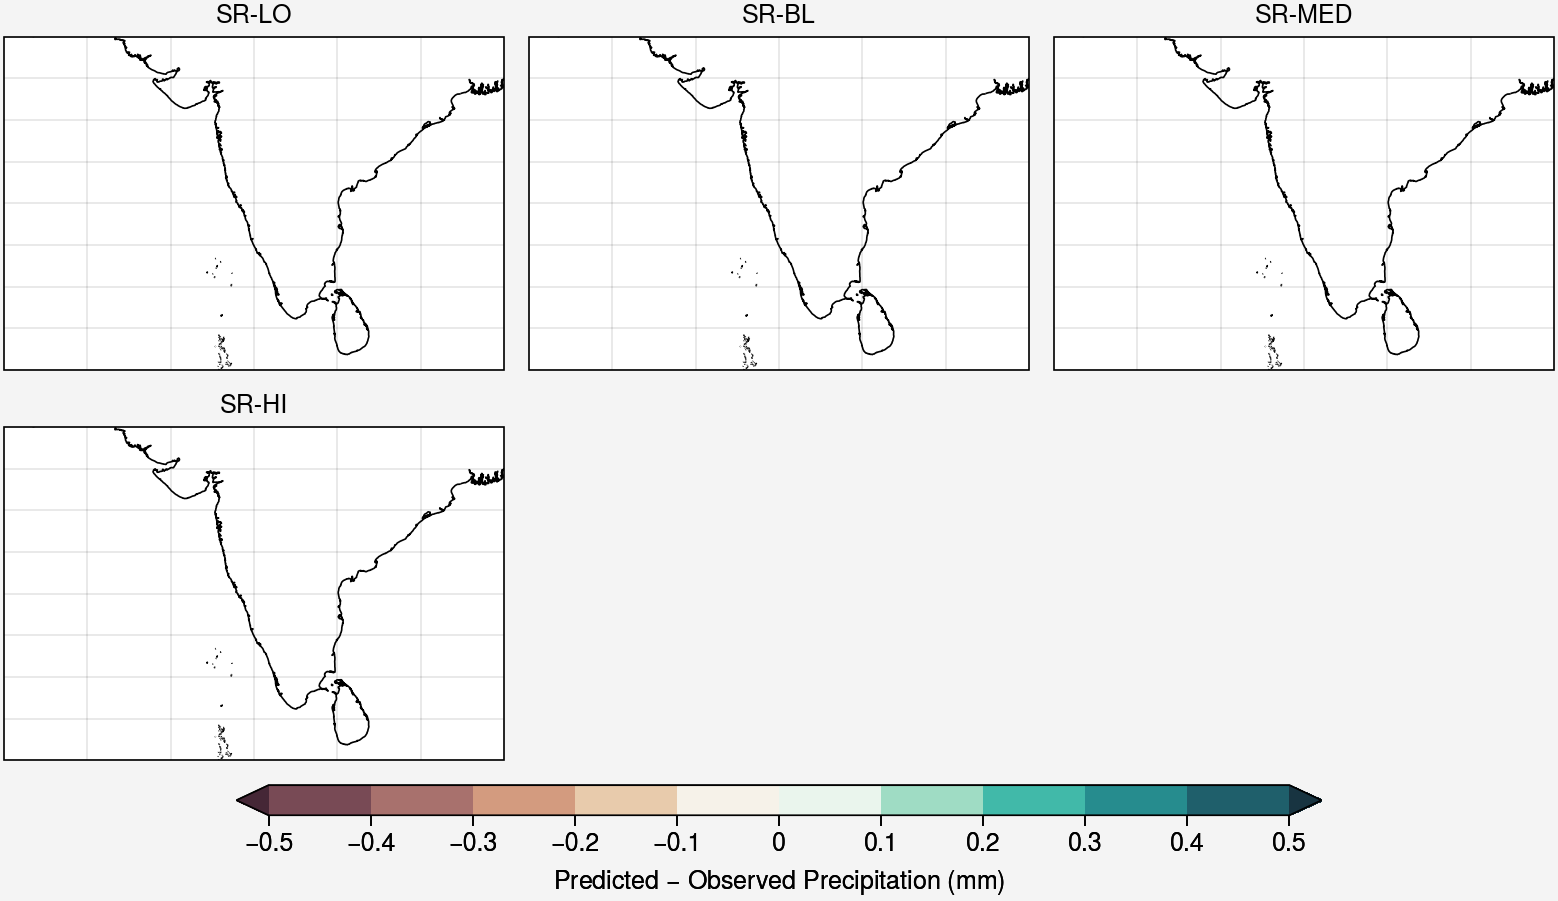

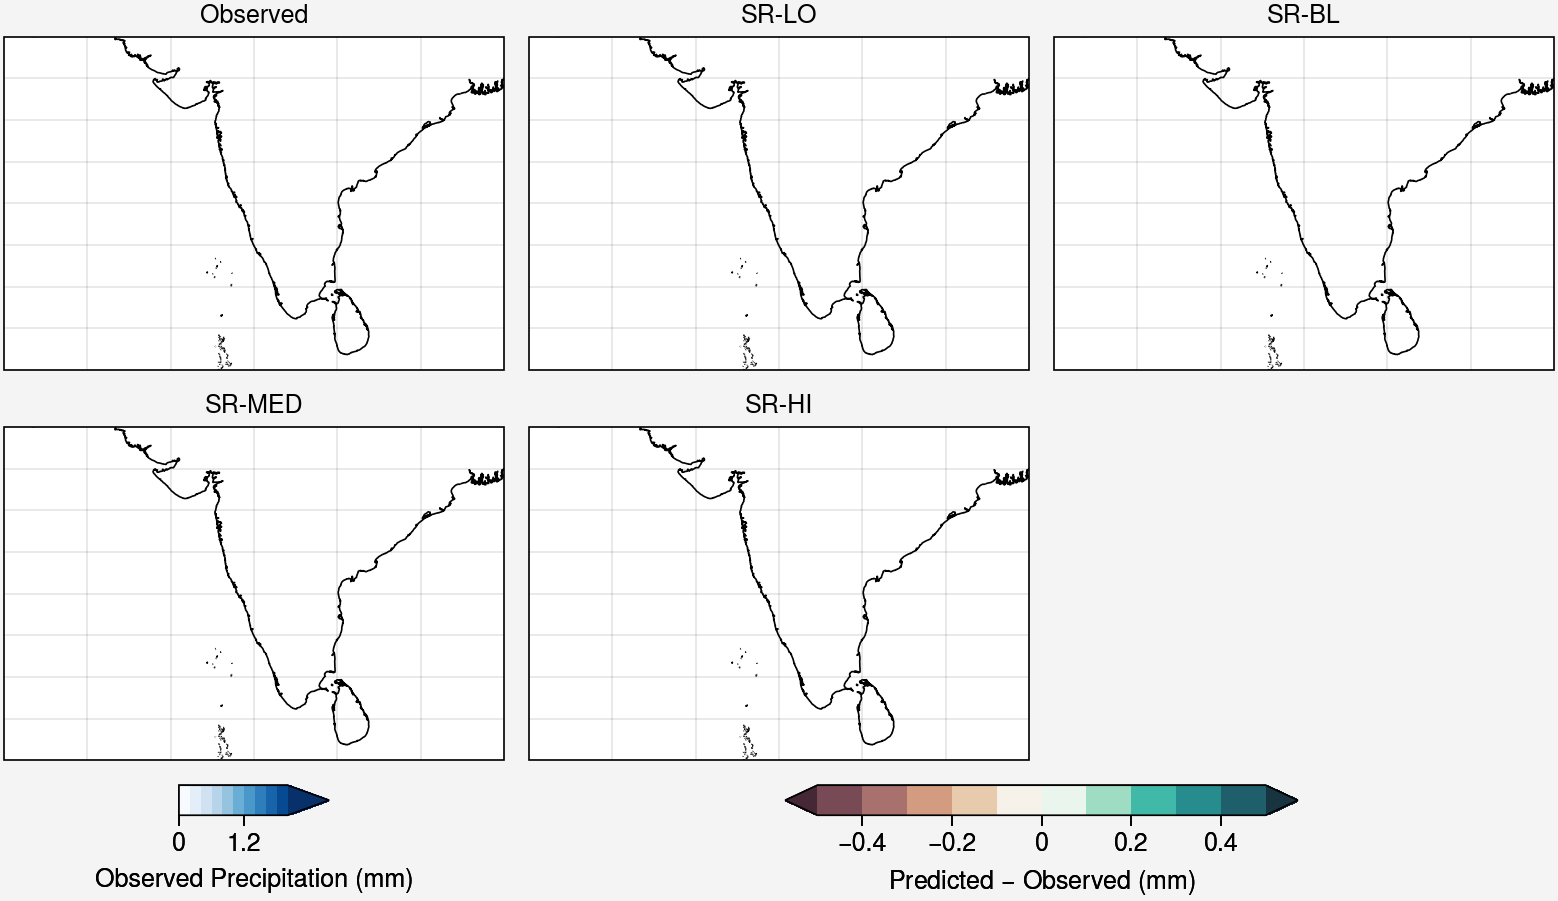

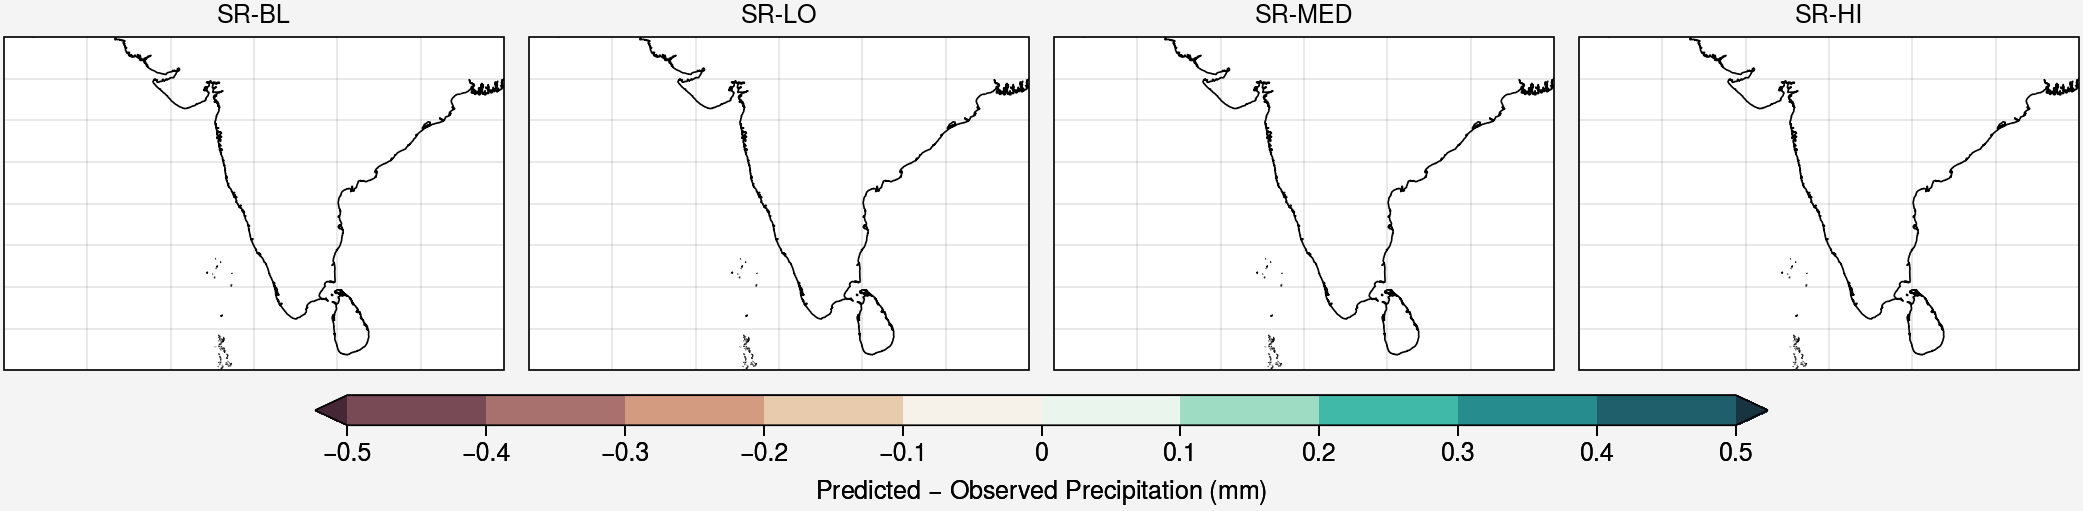

In [11]:
import cartopy.crs as ccrs

def plot_spatial_residuals(names=None, vlim=0.5):
    if names is None:
        names = [n for n in ORDER if n in resid_maps]
    ncols = min(3, len(names))
    nrows = -(-len(names) // ncols)
    fig, axs = pplt.subplots(
        nrows=nrows, ncols=ncols,
        proj='cyl', refwidth=2.5, share=True)
    axs = np.atleast_1d(axs).ravel()
    m = None
    for ax, name in zip(axs, names):
        m = ax.pcolormesh(
            lon, lat, resid_maps[name],
            cmap='DryWet', vmin=-vlim, vmax=vlim, extend='both',
            transform=ccrs.PlateCarree())
        ax.format(
            title=LABELS.get(name, name),
            latlim=(lat.min(), lat.max()),
            lonlim=(lon.min(), lon.max()),
            grid=True, gridminor=False,
            coast=True, borders=False)
    for ax in axs[len(names):]:
        ax.set_visible(False)
    fig.colorbar(m, loc='b', label='Predicted $-$ Observed Precipitation (mm)',
                 width=0.15, length=0.7)
    pplt.show()

def plot_obs_and_residuals(names=None, vlim=0.5):
    if names is None:
        names = [n for n in ORDER if n in resid_maps]
    all_panels = ['obs'] + names
    ncols = min(3, len(all_panels))
    nrows = -(-len(all_panels) // ncols)
    fig, axs = pplt.subplots(
        nrows=nrows, ncols=ncols,
        proj='cyl', refwidth=2.5, share=True)
    axs = np.atleast_1d(axs).ravel()
    mc, mr = None, None
    for ax, panel in zip(axs, all_panels):
        if panel == 'obs':
            mc = ax.pcolormesh(
                lon, lat, obs_map,
                cmap='Blues', vmin=0, vmax=2, extend='max',
                transform=ccrs.PlateCarree())
            ax.format(title='Observed')
        else:
            mr = ax.pcolormesh(
                lon, lat, resid_maps[panel],
                cmap='DryWet', vmin=-vlim, vmax=vlim, extend='both',
                transform=ccrs.PlateCarree())
            ax.format(title=LABELS.get(panel, panel))
        ax.format(
            latlim=(lat.min(), lat.max()),
            lonlim=(lon.min(), lon.max()),
            grid=True, gridminor=False,
            coast=True, borders=False)
    for ax in axs[len(all_panels):]:
        ax.set_visible(False)
    if mc is not None:
        fig.colorbar(mc, loc='b', label='Observed Precipitation (mm)',
                     width=0.15, length=0.3, col=1)
    if mr is not None:
        fig.colorbar(mr, loc='b', label='Predicted $-$ Observed (mm)',
                     width=0.15, length=0.5, col=(2, ncols))
    pplt.show()

def plot_sr_residual_progression(vlim=0.5):
    sr_names = [n for n in ['sr_bl','sr_lo','sr_med','sr_hi'] if n in resid_maps]
    fig, axs = pplt.subplots(
        nrows=1, ncols=len(sr_names),
        proj='cyl', refwidth=2.5, share=True)
    axs = np.atleast_1d(axs).ravel()
    m = None
    for ax, name in zip(axs, sr_names):
        m = ax.pcolormesh(
            lon, lat, resid_maps[name],
            cmap='DryWet', vmin=-vlim, vmax=vlim, extend='both',
            transform=ccrs.PlateCarree())
        ax.format(
            title=LABELS.get(name, name),
            latlim=(lat.min(), lat.max()),
            lonlim=(lon.min(), lon.max()),
            grid=True, gridminor=False,
            coast=True, borders=False)
    fig.colorbar(m, loc='b', label='Predicted $-$ Observed Precipitation (mm)',
                 width=0.15, length=0.7)
    pplt.show()

plot_spatial_residuals()
plot_obs_and_residuals()
plot_sr_residual_progression()